<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/classification_naive_bayes_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Pengolahan dan visualisasi data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Natural Language Processing (NLP)
import string
import nltk
from nltk.corpus import stopwords
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Unduh daftar stopwords dari NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
url = 'https://raw.githubusercontent.com/justmarkham/' \
 'pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None,
 names=['label', 'message'])
# Tampilkan 5 baris pertama
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


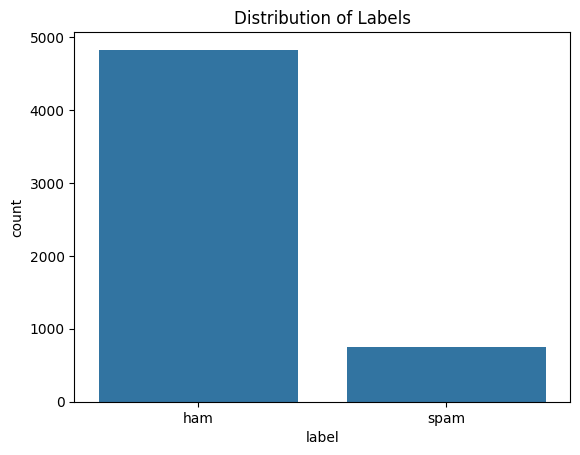

In [8]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.show()

In [9]:
def preprocess_text(text):
 # 1. Hilangkan tanda baca
 remove_punc = [char for char in text
 if char not in string.punctuation]
 remove_punc = ''.join(remove_punc)
 # 2. Huruf kecil semua & 3. buang stopwords
 cleaned_words = [word.lower()
 for word in remove_punc.split()
 if word.lower() not in stopwords.words('english')]
 return ' '.join(cleaned_words)

In [10]:
df['cleaned_message'] = df['message'].apply(preprocess_text)
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [11]:
# Inisialisasi CountVectorizer
vectorizer = CountVectorizer()
# Ubah pesan bersih menjadi vektor numerik (X)
X = vectorizer.fit_transform(df['cleaned_message'])
# Variabel target (y)
y = df['label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 4457
Testing samples: 1115


In [13]:
# Inisialisasi model Multinomial Naive Bayes
nb_model = MultinomialNB()
# Latih model
nb_model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [16]:
y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 97.49%
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       966
        spam       0.88      0.95      0.91       149

    accuracy                           0.97      1115
   macro avg       0.93      0.96      0.95      1115
weighted avg       0.98      0.97      0.98      1115



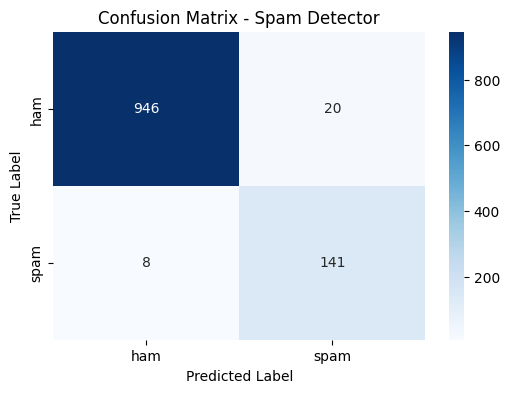

In [17]:
cm = confusion_matrix(y_test, y_pred,
 labels=['ham', 'spam'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=['ham', 'spam'],
 yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Spam Detector')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [18]:
def predict_message(custom_message):
 # 1. Bersihkan pesan masuk
 cleaned = preprocess_text(custom_message)
 # 2. Vektorkan dengan vectorizer dari Langkah 4
 vectorized = vectorizer.transform([cleaned])
 # 3. Prediksi
 prediction = nb_model.predict(vectorized)
 return prediction

In [20]:
user_message = "Congratulations for getting 500USD voucher"
result = predict_message(user_message)
print(f"Prediction: {result}") # -> spam

Prediction: ['spam']
